<a href="https://colab.research.google.com/github/DannyJung23/SatelliteDataAI-UoA/blob/main/My-Lab-Notebooks/761_Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Set up

In [30]:
# Set up GEE API
import ee
ee.Authenticate()
ee.Initialize(project='uoa-gisci')

In [43]:
# Install the geemap package
!pip install geemap --quiet

In [32]:
# Importing libraries
import geemap
import ipywidgets as widgets
from ipyleaflet import WidgetControl
import matplotlib.pyplot as plt

In [33]:
# Reusable cartographic elements

# North arrow
north_arrow = widgets.HTML(
    value = """
    <div style="
        background-color: white;
        padding: 6px 10px;
        border-radius: 4px;
        text-align: center;
        font-family: Arial;
        font-size: 20px;
        font-weight: bold;
        color: black;
        box-shadow: 0 1px 4px rgba(0,0,0,0.4);
    ">
        ↑<br>
        <span style="font-size: 14px; color: black;">N</span>
    </div>
    """
)

north_arrow_control = WidgetControl(
    widget=north_arrow,
    position="topright"
)

# Loading a map and displaying satellite data

(1) Find and add the basemap 'OpenTopoMap' to the display window AND change the code so that the map opens and zooms to the city of Auckland. Provide a link to your code in a notebook and the output as a figure in the answer proforma. (2 pts)

**Code for Q1**

In [34]:
# Create map centred on Auckland city
Map_q1 = geemap.Map(
    center=(-36.8485, 174.7633), zoom=12, scale_ctrl=True
)

Map_q1.add_basemap("OpenTopoMap")
Map_q1.add_control(north_arrow_control)

Map_q1

Map(center=[-36.8485, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

(2) The Landsat 7 data displays as red colored/tinged image. Why is this? [Think about both the content in Lecture 1, and what is going on when you visualize a satellite image]. (2 pts)

In [35]:
# Add Earth Engine datasets to the map by creating variables to hold the calls to the EE api
Map_q2 = geemap.Map(center=(-41, 172), zoom=4)
dem = ee.Image("USGS/SRTMGL1_003")
landcover = ee.Image("ESA/GLOBCOVER_L4_200901_200912_V2_3").select("landcover")
landsat7 = ee.Image("LANDSAT/LE7_TOA_5YEAR/1999_2003")
states = ee.FeatureCollection("TIGER/2018/States")

In [36]:
# Set visualization parameters for DEM
vis_params = {
    "min": 0,
    "max": 4000, # check and change this vis param if the image is shown as all white or all black
    "palette": ["006633", "E5FFCC", "662A00", "D8D8D8", "F5F5F5"]
}

In [37]:
# Add different Earth Engine Layers to the Map object
Map_q2.addLayer(dem, vis_params, "SRTM DEM", True, 0.5)
Map_q2.addLayer(landcover, {}, ":Land cover")
Map_q2.addLayer(
    landsat7, {"bands": ["B4", "B3", "B2"], "min": 20, "max": 200}, "Landsat 7"
)
Map_q2.addLayer(states, {}, "US States")

Map_q2

Map(center=[-41, 172], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tr…

(3) Correct the display of the Landsat 7 image so that it displays in 'True Colour'. Provide a notebook example of your code and the corrected output over the whole of New Zealand. (10 pts)

**Code for Q3**

In [38]:
# Add Earth Engine datasets to the map
Map_q3 = geemap.Map(center=(-41, 172), zoom=5, scale_ctrl=True)
dem = ee.Image("USGS/SRTMGL1_003")
landcover = ee.Image("ESA/GLOBCOVER_L4_200901_200912_V2_3").select("landcover")
landsat7 = ee.Image("LANDSAT/LE7_TOA_5YEAR/1999_2003")

# Set visualization parameters
dem_vis_params = {
    "min": 0,
    "max": 4000,
    "palette": ["006633", "E5FFCC", "662A00", "D8D8D8", "F5F5F5"]
}

landsat_vis_params = {
    "bands": ["B3", "B2", "B1"], # Red, Green, Blue
    "min": 0,
    "max": 100 # min/max values adjusted for better colour contrast
}

# Add the Earth Engine Layers to the Map object
Map_q3.addLayer(dem, dem_vis_params, "SRTM DEM", True, 0.5)
Map_q3.addLayer(landcover, {}, ":Land cover")
Map_q3.addLayer(
    landsat7, landsat_vis_params, "Landsat 7 True Colour"
)

Map_q3.add_control(north_arrow_control)

Map_q3

Map(center=[-41, 172], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tr…

# Spectral reflectance curves

In [39]:
# Define a point and a small rectangular region around it
point = ee.Geometry.Point([174.7633, -36.8485]) # Auckland
region = point.buffer(150).bounds() # ~300m box

# Load a Landsat 7 Collection 2 Level 2 Surface Reflectance image
image = (
  ee.ImageCollection('LANDSAT/LE07/C02/T1_L2')
  .filterBounds(region)
  .filterDate('2002-01-01', '2002-12-31')
  .sort('CLOUD_COVER')
  .first()
)

(4) Why are we using the surface reflectance (SR) here rather than the top of atmosphere (ToA)? (2 pt)

In [40]:
# Select surface reflectance bands and apply scale factor
bands = ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7']
band_names = {
    'SR_B1': 'Blue (0.45–0.52 μm)',
    'SR_B2': 'Green (0.52–0.60 μm)',
    'SR_B3': 'Red (0.63–0.69 μm)',
    'SR_B4': 'NIR (0.77–0.90 μm)',
    'SR_B5': 'SWIR1 (1.55–1.75 μm)',
    'SR_B7': 'SWIR2 (2.09–2.35 μm)'
}

scale_factor = 2.75e-5 # From USGS documentation for Landsat C2 L2

(5) What is a 'scale factor' as has been used in the prior code cell, and why are they used in satellite data storage-to-processing workflows such as this? (2 pts)

Using a reduce operation over the specified small sample area in order to find the mean of all the cells that lie within the region.

In [41]:
# Reduce region to mean reflectance
mean_dict = image.select(bands).reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=region,
    scale=30,
    maxPixels=1e6
)

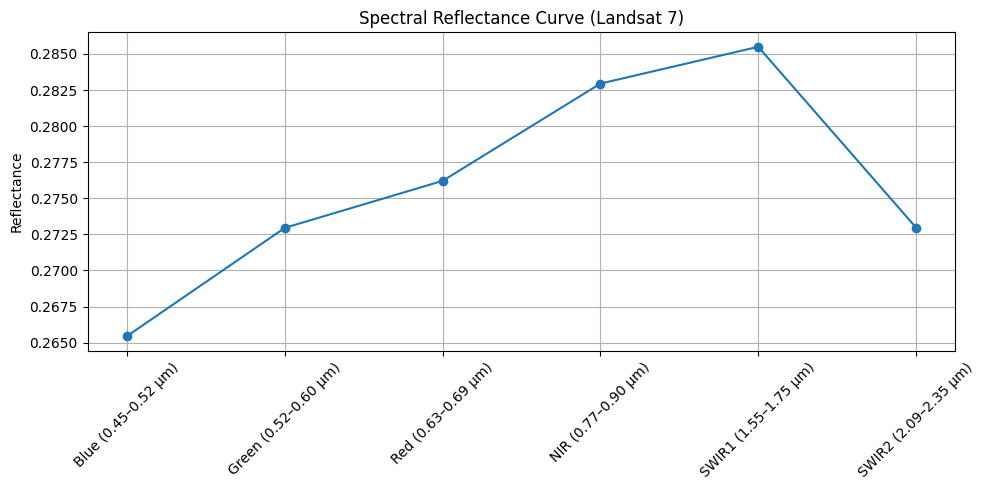

In [42]:
# Extract and scale values
mean_values = mean_dict.getInfo()
reflectance = [mean_values[b] * scale_factor for b in bands]

# Plot the spectral curve
plt.figure(figsize=(10, 5))
plt.plot(list(band_names.values()), reflectance, marker='o', linestyle='-')
plt.title('Spectral Reflectance Curve (Landsat 7)')
plt.ylabel('Reflectance')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

(6) If we want to apply multiple reducers to the same inputs what is a more efficient way to do so than just writing out a long series of sequential reducers on our end? (2 pts)

# Cloud cover

Basic cloud masking for Landsat 7